# Predicción de Satisfacción de Clientes con Random Forest

---

**Autor:** Borja Mora Méndez
**Contacto:** [borja.mora.mendez@gmail.com](mailto:borja.mora.mendez@gmail.com) · [LinkedIn](https://www.linkedin.com/in/borja-mora-mendez/)
**Repositorio:** [Data Analytics Portfolio](https://github.com/BORJAMOME/Data-Analytics-Portfolio)
**Categoría:** Machine Learning · Supervisado · Clasificación · Random Forest

---

### Objetivo

Entrenar un **Random Forest Classifier** para predecir la satisfacción de clientes de un gimnasio urbano, analizar qué variables operativas la explican y evaluar si la robustez de un ensemble de 100 árboles aporta un beneficio real frente a un árbol de decisión simple.

**El cliente:** cadena de gimnasios urbanos con múltiples sedes.

**El problema:** la dirección necesita predecir qué clientes están insatisfechos para actuar antes de que se den de baja. Las encuestas de satisfacción son caras, lentas y llegan tarde. Se quiere un modelo basado en datos operativos que el gimnasio ya recoge.

## 1️. Setup: librerías y configuración visual

In [12]:
# Librerías base
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocesamiento
from sklearn.model_selection import train_test_split, cross_val_score

# Modelos
from sklearn.ensemble import RandomForestClassifier

# Métricas
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
)
from sklearn.inspection import permutation_importance

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", None)

# Estilo visual
PURPLE = '#7a7bff'
GREEN  = '#6E7F5B'
RED    = '#C2412E'
GRAY   = '#F4EFE6'
INK    = '#2B2118'
MUTED  = '#bfbfbf'

plt.rcParams.update({
    'figure.figsize': (10, 5),
    'figure.dpi': 100,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.edgecolor': MUTED,
    'axes.labelcolor': INK,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.titlecolor': INK,
    'xtick.color': MUTED,
    'ytick.color': MUTED,
    'font.family': 'sans-serif',
    'font.size': 10,
    'grid.color': '#f0f0f0',
    'grid.linewidth': 0.5,
})

## 2. Carga de datos

In [13]:
data = pd.read_excel("gym_clientes.xlsx")
print(f"Registros: {data.shape[0]} | Columnas: {data.shape[1]}")
data.head()

Registros: 300 | Columnas: 7


,ID_Cliente,Antiguedad_Meses,Asistencias_Mes,Horas_Pico_Mes,Gasto_Mensual_Extra,Satisfecho,Abandono
0,1,29,1,8.673509,64.161055,0,1
1,2,15,1,4.396600,32.554177,0,0
2,3,8,22,22.313433,85.092643,1,0
3,4,21,21,20.598791,120.709423,1,0
4,5,19,18,18.783644,103.148141,1,0


## 3. EDA: Análisis Exploratorio de datos

In [14]:
data.describe().round(2)

,ID_Cliente,Antiguedad_Meses,Asistencias_Mes,Horas_Pico_Mes,Gasto_Mensual_Extra,Satisfecho,Abandono
count,300.00,300.00,300.00,300.00,300.00,300.00,300.00
mean,150.50,18.88,12.16,14.67,81.69,0.48,0.16
std,86.75,10.60,7.27,6.09,30.47,0.50,0.37
min,1.00,1.00,0.00,1.41,10.00,0.00,0.00
25%,75.75,9.00,6.00,9.65,61.25,0.00,0.00
50%,150.50,20.00,12.00,15.07,82.24,0.00,0.00
75%,225.25,28.00,18.25,19.75,104.11,1.00,0.00
max,300.00,35.00,24.00,24.00,145.91,1.00,1.00


In [15]:
# Comprobar nulos y tipos

print('TIPOS DE DATOS Y VALORES NULOS')
print('─' * 70)
info = pd.DataFrame({
    'Tipo': data.dtypes,
    'Nulos': data.isnull().sum(),
    '% Nulos': (data.isnull().sum() / len(data) * 100).round(2),
    'Únicos': data.nunique()
})
info

TIPOS DE DATOS Y VALORES NULOS
──────────────────────────────────────────────────────────────────────


,Tipo,Nulos,% Nulos,Únicos
ID_Cliente,int64,0,0.0,300
Antiguedad_Meses,int64,0,0.0,35
Asistencias_Mes,int64,0,0.0,25
Horas_Pico_Mes,float64,0,0.0,281
Gasto_Mensual_Extra,float64,0,0.0,300
Satisfecho,int64,0,0.0,2
Abandono,int64,0,0.0,2


#### Exploración de la variable Target (Satisfecho)

In [16]:
sat_rate = data["Satisfecho"].value_counts(normalize=True)
print("Distribución del target:")
print(f"  No Satisfecho (0): {sat_rate[0]:.1%}")
print(f"  Satisfecho (1):    {sat_rate[1]:.1%}")
print("\nClases equilibradas (52/48) — accuracy es métrica fiable sin ajustes.")

Distribución del target:
  No Satisfecho (0): 52.0%
  Satisfecho (1):    48.0%

Clases equilibradas (52/48) — accuracy es métrica fiable sin ajustes.


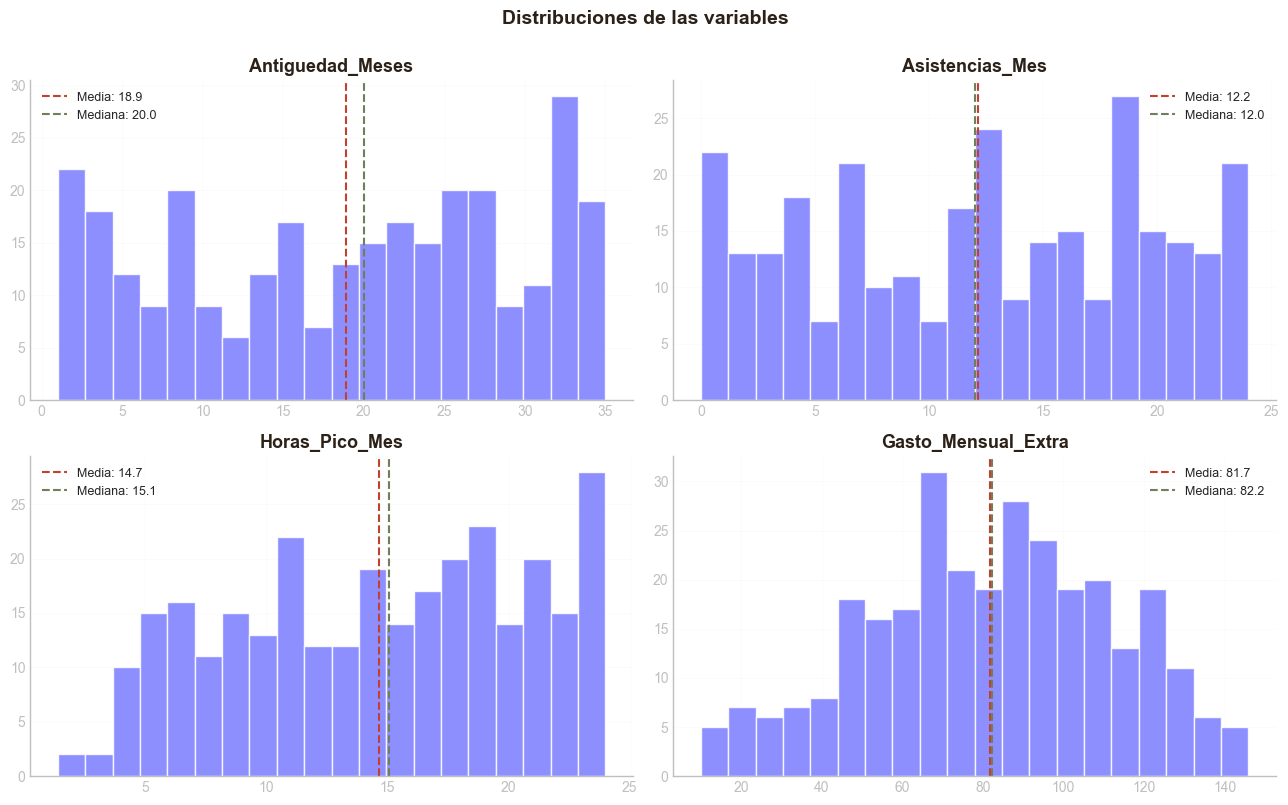

In [17]:
# Distribuciones de cada variable

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
fig.suptitle('Distribuciones de las variables', fontsize=14, fontweight='bold', color=INK, y=1.00)

variables = ["Antiguedad_Meses", "Asistencias_Mes", "Horas_Pico_Mes", "Gasto_Mensual_Extra"]
for ax, var in zip(axes.flat, variables):
    ax.hist(data[var], bins=20, color=PURPLE, edgecolor='white', alpha=0.85)
    ax.axvline(data[var].mean(), color=RED, linestyle='--', linewidth=1.5, label=f'Media: {data[var].mean():.1f}')
    ax.axvline(data[var].median(), color=GREEN, linestyle='--', linewidth=1.5, label=f'Mediana: {data[var].median():.1f}')
    ax.set_title(var, color=INK)
    ax.legend(fontsize=9, frameon=False)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

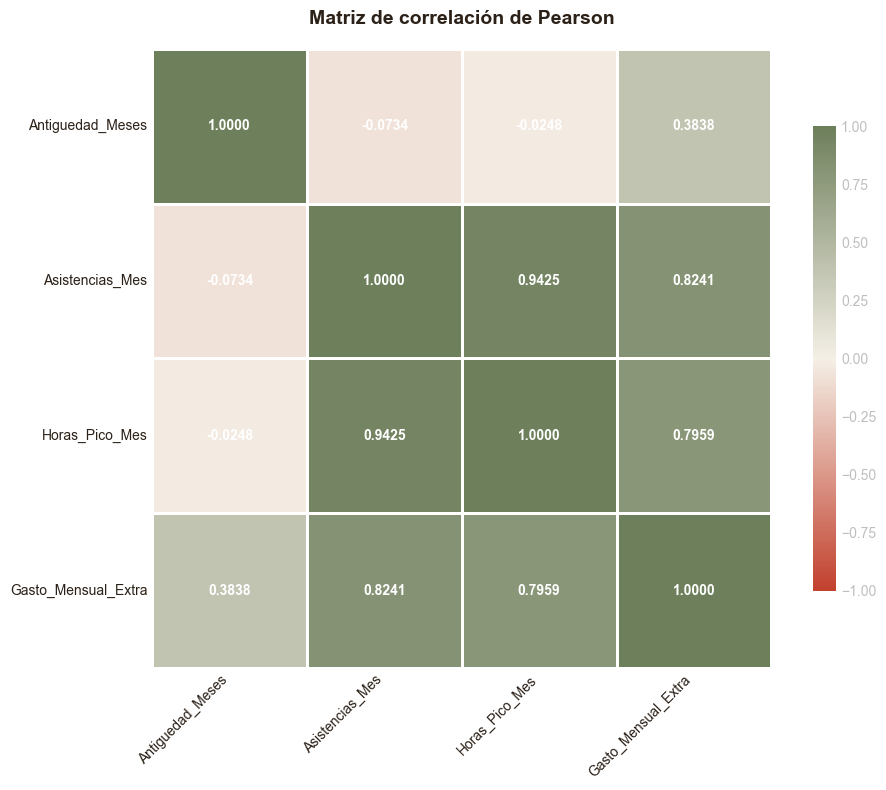

In [18]:
# Matriz de correlación

from matplotlib.colors import LinearSegmentedColormap

cols_num = ["Antiguedad_Meses", "Asistencias_Mes", "Horas_Pico_Mes", "Gasto_Mensual_Extra"]

# Mapa de colores personalizado
cmap = LinearSegmentedColormap.from_list(
    "custom_corr",
    [RED, GRAY, GREEN],
    N=256
)

# Matriz de correlación
corr = data[cols_num].corr()

fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    corr,
    annot=True,
    fmt=".4f",
    cmap=cmap,
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=1,
    linecolor="white",
    cbar_kws={"shrink": 0.75},
    annot_kws={
        "size": 10,
        "weight": "bold",
        "color": "white"
    },
)

ax.set_title(
    "Matriz de correlación de Pearson",
    fontsize=14,
    fontweight="bold",
    color=INK,
    pad=18,
)

ax.tick_params(colors=INK)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

### Columna del target (Satisfacción)

- ``Asistencias_Mes``: correlación positiva fuerte → los clientes que acuden con mayor frecuencia al gimnasio tienden a mostrar una mayor satisfacción.
- ``Horas_Pico_Mes``: correlación positiva fuerte → un mayor uso de las instalaciones, incluso en horas punta, está asociado con clientes más satisfechos.
- ``Gasto_Mensual_Extra``: correlación positiva fuerte → los clientes que invierten más en servicios adicionales suelen presentar niveles más altos de satisfacción.
- ``Antiguedad_Meses``: correlación positiva moderada → los clientes con más tiempo en el gimnasio muestran una ligera tendencia a estar más satisfechos, aunque la relación es menor que en el resto de variables.

### Entre variables predictoras

- ``Antiguedad_Meses ↔ Asistencias_Mes``: **-0.0734** → correlación muy débil y negativa.
- ``Antiguedad_Meses ↔ Horas_Pico_Mes``: **-0.0248** → correlación prácticamente nula.
- ``Antiguedad_Meses ↔ Gasto_Mensual_Extra``: **0.3838** → correlación moderada y positiva.
- ``Asistencias_Mes ↔ Horas_Pico_Mes``: **0.9425** → correlación muy fuerte y positiva.
- ``Asistencias_Mes ↔ Gasto_Mensual_Extra``: **0.8241** → correlación fuerte y positiva.
- ``Horas_Pico_Mes ↔ Gasto_Mensual_Extra``: **0.7959** → correlación fuerte y positiva.

### Conclusión

Las variables relacionadas con el **uso del gimnasio** (asistencia, horas de uso y gasto en servicios adicionales) muestran una relación positiva con la satisfacción de los clientes, lo que indica que los usuarios más implicados suelen estar más satisfechos.

Además, existe una correlación muy elevada entre ``Asistencias_Mes`` y ``Horas_Pico_Mes`` (**0.9425**), por lo que ambas variables aportan información muy similar.

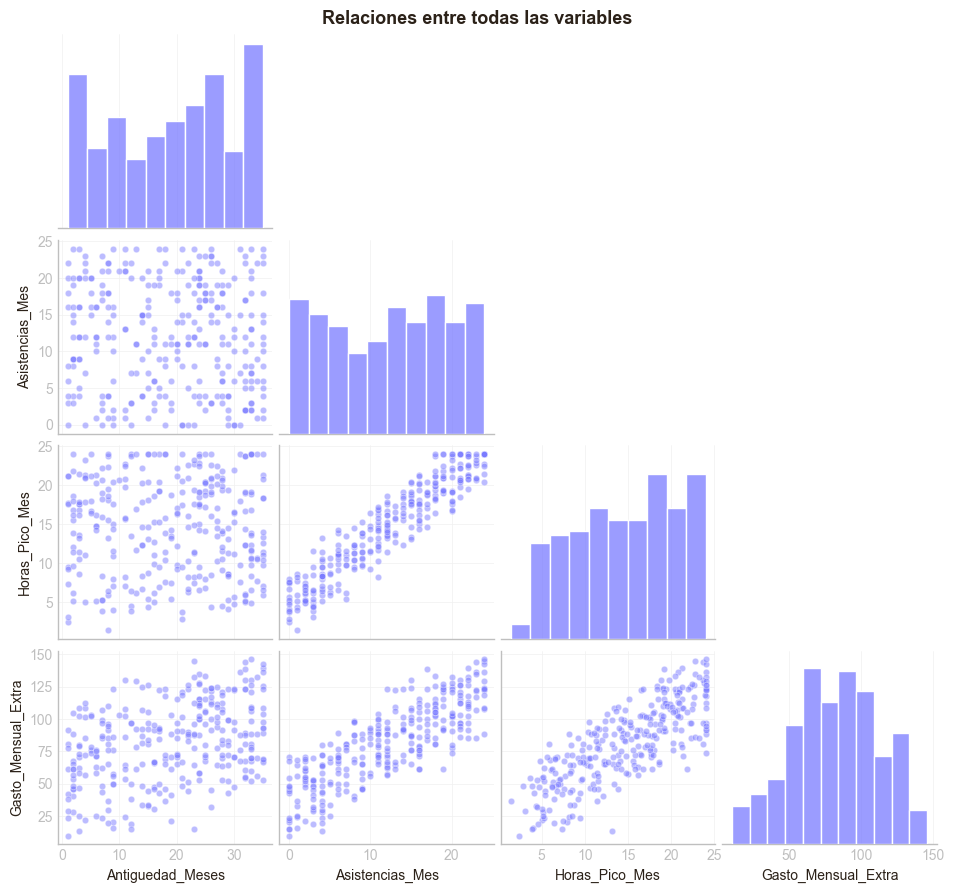

In [19]:
# Pair plot: relaciones por parejas
g = sns.pairplot(
    data[cols_num], height=2.2, aspect=1.1,
    plot_kws={'color': PURPLE, 'alpha': 0.5, 's': 22, 'edgecolor': 'white', 'linewidth': 0.5},
    diag_kws={'color': PURPLE, 'edgecolor': 'white'},
    corner=True
)
g.fig.suptitle('Relaciones entre todas las variables', y=1.01, fontsize=13, fontweight='bold', color=INK)
plt.show()

## 4. Train / Test Split
Excluimos `Abandono` para evitar data leakage — un cliente que se ha dado de baja es, por definición, insatisfecho. Si la incluyéramos, el modelo "haría trampa".

In [20]:
X = data[["Antiguedad_Meses", "Asistencias_Mes", "Horas_Pico_Mes", "Gasto_Mensual_Extra"]]
y = data["Satisfecho"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]} registros ({y_train.mean():.1%} satisfechos)")
print(f"Test:  {X_test.shape[0]} registros ({y_test.mean():.1%} satisfechos)")

Train: 240 registros (47.9% satisfechos)
Test:  60 registros (48.3% satisfechos)


## 5. Modelo principal — Random Forest

### Selección de hiperparámetros con validación cruzada

Evaluamos el impacto del número de árboles (`n_estimators`) en el rendimiento, para determinar si 100 es suficiente o si más árboles mejoran el resultado.

  n_estimators= 10 → CV accuracy: 0.9083
  n_estimators= 25 → CV accuracy: 0.9125
  n_estimators= 50 → CV accuracy: 0.9167
  n_estimators=100 → CV accuracy: 0.9125
  n_estimators=200 → CV accuracy: 0.9167
  n_estimators=300 → CV accuracy: 0.9167


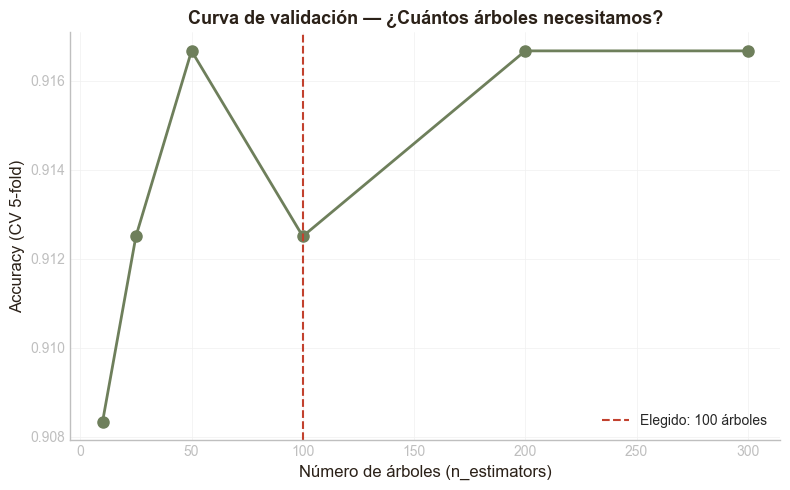


Con 100 árboles el rendimiento se estabiliza — más árboles no mejoran el resultado.


In [26]:
n_trees_range = [10, 25, 50, 100, 200, 300]
cv_scores = []

for n in n_trees_range:
    rf_temp = RandomForestClassifier(n_estimators=n, random_state=42)
    score = cross_val_score(rf_temp, X_train, y_train, cv=5, scoring="accuracy").mean()
    cv_scores.append(score)
    print(f"  n_estimators={n:>3d} → CV accuracy: {score:.4f}")

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(n_trees_range, cv_scores, marker="o", color=GREEN, linewidth=2, markersize=8)
ax.axvline(x=100, color=RED, linestyle="--", linewidth=1.5, label="Elegido: 100 árboles")
ax.set_xlabel("Número de árboles (n_estimators)", fontsize=12)
ax.set_ylabel("Accuracy (CV 5-fold)", fontsize=12)
ax.set_title("Curva de validación — ¿Cuántos árboles necesitamos?", fontsize=13, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

print("\nCon 100 árboles el rendimiento se estabiliza — más árboles no mejoran el resultado.")

### Entrenamiento y evaluación

In [22]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print("Random Forest — Métricas de evaluación")
print(f"Accuracy:  {acc:.1%}")
print(f"Recall:    {rec:.1%}")
print(f"AUC-ROC:   {auc:.3f}")
print()
print(classification_report(y_test, y_pred, target_names=["No Satisfecho", "Satisfecho"]))

Random Forest — Métricas de evaluación
Accuracy:  90.0%
Recall:    89.7%
AUC-ROC:   0.917

               precision    recall  f1-score   support

No Satisfecho       0.90      0.90      0.90        31
   Satisfecho       0.90      0.90      0.90        29

     accuracy                           0.90        60
    macro avg       0.90      0.90      0.90        60
 weighted avg       0.90      0.90      0.90        60



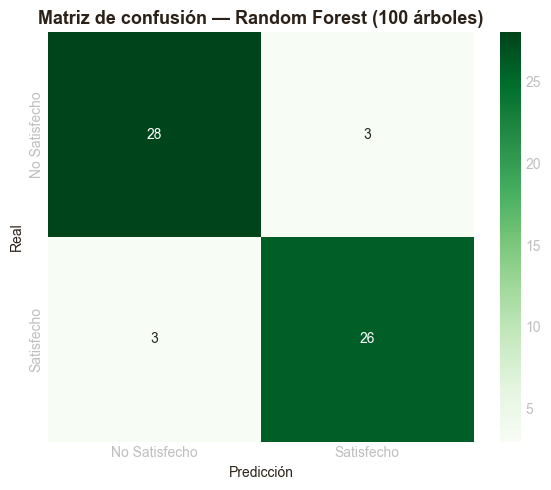

In [23]:
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=["No Satisfecho", "Satisfecho"],
            yticklabels=["No Satisfecho", "Satisfecho"], ax=ax)
ax.set_title("Matriz de confusión — Random Forest (100 árboles)", fontsize=13, fontweight="bold")
ax.set_xlabel("Predicción")
ax.set_ylabel("Real")
plt.tight_layout()
plt.show()

**Interpretación:**

El Random Forest logra un **90,0% de accuracy** con un **AUC-ROC de 0,917**. La matriz de confusión muestra 6 errores sobre 60 predicciones — exactamente los mismos que un árbol simple con `max_depth=2`. Esto es significativo: 100 árboles entrenados sobre submuestras aleatorias no mejoran la precisión del modelo más simple. La señal en este dataset es tan clara y concentrada en una variable (`Asistencias_Mes`) que la complejidad adicional del ensemble no aporta.

### Importancia de variables — Gini vs Permutación


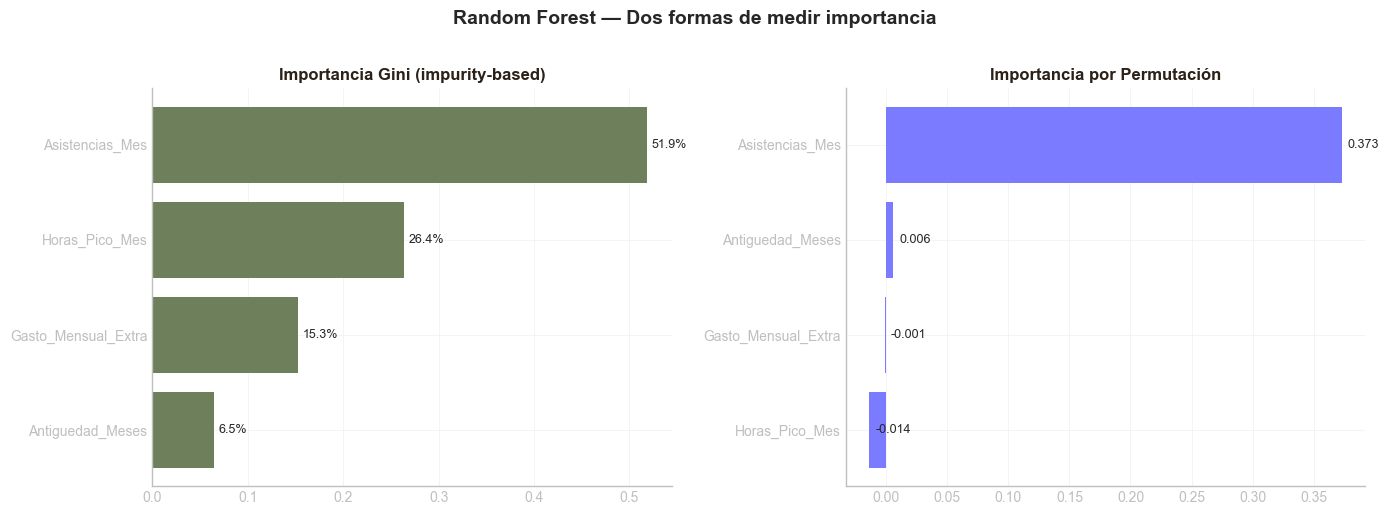

Ranking Gini:
  Asistencias_Mes           51.9%
  Horas_Pico_Mes            26.4%
  Gasto_Mensual_Extra       15.3%
  Antiguedad_Meses          6.5%

Ranking Permutación:
  Asistencias_Mes           0.3728
  Antiguedad_Meses          0.0056
  Gasto_Mensual_Extra       -0.0011
  Horas_Pico_Mes            -0.0139


In [27]:
# Importancia Gini (por defecto en sklearn)
imp_gini = pd.DataFrame({
    "feature": X.columns,
    "importance_gini": rf.feature_importances_
}).sort_values("importance_gini", ascending=False)

# Importancia por permutación (más robusta)
perm_result = permutation_importance(rf, X_test, y_test, n_repeats=30, random_state=42)
imp_perm = pd.DataFrame({
    "feature": X.columns,
    "importance_perm": perm_result.importances_mean
}).sort_values("importance_perm", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(imp_gini["feature"], imp_gini["importance_gini"], color=GREEN)
for i, v in enumerate(imp_gini["importance_gini"]):
    axes[0].text(v + 0.005, i, f"{v:.1%}", va="center", fontsize=9)
axes[0].invert_yaxis()
axes[0].set_title("Importancia Gini (impurity-based)", fontsize=12, fontweight="bold")

axes[1].barh(imp_perm["feature"], imp_perm["importance_perm"], color=PURPLE)
for i, v in enumerate(imp_perm["importance_perm"]):
    axes[1].text(v + 0.005, i, f"{v:.3f}", va="center", fontsize=9)
axes[1].invert_yaxis()
axes[1].set_title("Importancia por Permutación", fontsize=12, fontweight="bold")

plt.suptitle("Random Forest — Dos formas de medir importancia", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print("Ranking Gini:")
for _, row in imp_gini.iterrows():
    print(f"  {row['feature']:25s} {row['importance_gini']:.1%}")
print("\nRanking Permutación:")
for _, row in imp_perm.iterrows():
    print(f"  {row['feature']:25s} {row['importance_perm']:.4f}")

**Lectura:**

Ambos métodos coinciden en que `Asistencias_Mes` es la variable dominante, seguida de `Horas_Pico_Mes` y `Gasto_Mensual_Extra`. `Antiguedad_Meses` aporta una importancia marginal.


## 6. Insights de negocio y recomendaciones


### El hallazgo

> El **Random Forest confirma el mismo patrón observado en el Árbol de Decisión**: la **frecuencia de asistencia** es, con diferencia, el principal factor que explica la satisfacción de los clientes. Aunque el modelo analiza múltiples combinaciones de variables mediante 100 árboles, la asistencia sigue siendo la señal dominante.

### Recomendaciones

**1. Priorizar el seguimiento de la frecuencia de asistencia (impacto: alto, esfuerzo: bajo)**

La variable **Asistencias_Mes** concentra el **51,9% de la importancia Gini** y es la única que mantiene una importancia claramente positiva mediante **permutación** (0,373). Esto indica que monitorizar la frecuencia de asistencia proporciona la mayor capacidad para anticipar la satisfacción de los clientes.

**2. Simplificar los indicadores operativos (impacto: alto)**

Aunque el modelo incorpora cuatro variables, los resultados muestran que la mayor parte del poder predictivo procede de la frecuencia de asistencia. Variables como **Horas_Pico_Mes**, **Gasto_Mensual_Extra** y **Antiguedad_Meses** aportan información complementaria, pero su impacto es mucho menor. 

**3. Optimizar los recursos de fidelización (impacto: medio-alto)**

Los clientes cuya frecuencia de asistencia disminuya de forma continuada deberían incorporarse a campañas preventivas de retención. Actuar sobre este comportamiento probablemente tendrá un mayor impacto que diseñar acciones específicas basadas en la antigüedad o el consumo de servicios adicionales.
